# Democratic Resilience Panel: SWIID + V-Dem + Maddison + ToT Shocks

This notebook demonstrates the **Democratic Resilience Panel** dataset assembly pipeline.

Five data sources are merged into a single panel for studying economic inequality and democracy:
1. **SWIID v9.92** — Gini coefficients (disposable and market income) for 150+ countries post-1990
2. **V-Dem** — Electoral and liberal democracy indices (v2x_polyarchy, v2x_libdem)
3. **Maddison Project Database 2023** — GDP per capita in 2011 PPP USD, 178 countries
4. **World Bank WDI** — GDP growth, GDP per capita (PPP), Terms of Trade shocks
5. **Panel merge** — All sources joined on (iso3, year), filtered to T≥15 consecutive years

The panel covers **1990–2023**, with 4,441 primary rows across 150 countries. Each example has:
- `input`: JSON string with predictor features (democracy indices, GDP, inequality)
- `output`: target variable (`gini_disp`, the disposable income Gini coefficient)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pandas, pyarrow — pre-installed on Colab; install locally at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a47f25-automatic-stabilizers-for-democracy-coun/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

import os

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  panel_primary: 50 examples


## Config

All tunable parameters for the demo. Set to minimum values that produce meaningful output.
Increase `N_EXAMPLES` to use the full 50-example mini dataset, or scale higher with a larger data file.

In [5]:
# --- Config ---
N_EXAMPLES = 50          # how many examples to process (mini dataset has 50; original: 4441)
DATASET_NAME = "panel_primary"   # which dataset to use from the loaded data
MIN_YEAR = 1990          # filter: only rows from this year onward (original: 1990)
OUTPUT_COL = "gini_disp" # target variable (disposable income Gini)

## Helper Functions

These functions convert panel rows into the experiment-ready `{input, output}` format.
- `row_to_example`: takes a single row dict, formats predictors as JSON string and target as string
- `df_to_examples`: iterates rows of a DataFrame, calling `row_to_example` and attaching metadata

In [6]:
def row_to_example(row: dict, input_cols: list, output_col: str, meta: dict = None) -> dict:
    inp = {k: (None if pd.isna(v) else v) for k, v in row.items() if k in input_cols}
    out_val = row.get(output_col)
    example = {
        "input": json.dumps(inp, default=str),
        "output": str(round(float(out_val), 6)) if out_val is not None and not pd.isna(out_val) else "",
    }
    if meta:
        example.update(meta)
    return example


def df_to_examples(df: pd.DataFrame, input_cols: list, output_col: str, meta_cols: list = None) -> list:
    examples = []
    for idx, row in df.iterrows():
        row_d = row.to_dict()
        meta = {"metadata_row_index": int(idx)}
        if meta_cols:
            for mc in meta_cols:
                if mc in row_d and pd.notna(row_d[mc]):
                    meta[f"metadata_{mc}"] = row_d[mc]
        example = row_to_example(row_d, input_cols=input_cols, output_col=output_col, meta=meta)
        examples.append(example)
    return examples

## Processing: Panel Primary Dataset

Load the demo data (already in `{input, output}` format) and reconstruct a DataFrame for analysis.
This mirrors `load_panel_primary()` from `data.py`, which reads `panel_primary.parquet`, filters to post-1990 rows, and converts each row into an example with all non-target columns as inputs and `gini_disp` as the output.

In [7]:
# Find the target dataset in the loaded data
dataset_obj = next(d for d in data['datasets'] if d['dataset'] == DATASET_NAME)
examples = dataset_obj['examples'][:N_EXAMPLES]
print(f"Using {len(examples)} examples from '{DATASET_NAME}'")

# Reconstruct a flat DataFrame from the examples for exploration
rows = []
for ex in examples:
    inp = json.loads(ex['input'])
    inp[OUTPUT_COL] = float(ex['output']) if ex['output'] else None
    inp['metadata_iso3'] = ex.get('metadata_iso3', inp.get('iso3'))
    inp['metadata_year'] = ex.get('metadata_year', inp.get('year'))
    rows.append(inp)

df = pd.DataFrame(rows)
# Apply the same year filter as the original script
df = df[df['year'] >= MIN_YEAR].copy()
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Using 50 examples from 'panel_primary'
DataFrame shape: (50, 15)
Columns: ['year', 'gini_disp_se', 'gini_mkt', 'gini_mkt_se', 'iso3', 'v2x_polyarchy', 'v2x_libdem', 'gdppc_maddison', 'gdp_growth', 'gdppc_ppp_wb', 'terms_of_trade', 'ln_gdppc', 'gini_disp', 'metadata_iso3', 'metadata_year']


,year,gini_disp_se,gini_mkt,gini_mkt_se,iso3,v2x_polyarchy,v2x_libdem,gdppc_maddison,gdp_growth,gdppc_ppp_wb,terms_of_trade,ln_gdppc,gini_disp,metadata_iso3,metadata_year
0,1996,2.48,47.6,4.17,ALB,0.387,0.321,3965.685303,8.005514,5563.793151,NaN,8.285434,35.8,ALB,1996
1,1990,2.84,38.4,3.14,DZA,0.350,0.164,4697.000000,-1.668081,11728.545729,39.270450,8.454679,37.1,DZA,1990
2,2000,3.24,52.4,3.41,AGO,0.155,0.077,2013.636230,-0.302928,6796.406340,72.557235,7.607697,50.5,AGO,2000


## Processing: Convert to Example Format

Apply the same `df_to_examples` transformation as `data.py`: separate predictors (input) from the target (`gini_disp`) and attach ISO3/year metadata to each example.

In [8]:
input_cols = [c for c in df.columns if c not in [OUTPUT_COL, 'country', 'metadata_iso3', 'metadata_year']]
processed = df_to_examples(
    df=df,
    input_cols=input_cols,
    output_col=OUTPUT_COL,
    meta_cols=["iso3", "year"],
)
print(f"panel_primary: {len(processed)} examples")
print(f"\nExample[0] keys: {list(processed[0].keys())}")
print(f"input:  {processed[0]['input'][:120]}...")
print(f"output: {processed[0]['output']}")

panel_primary: 50 examples

Example[0] keys: ['input', 'output', 'metadata_row_index', 'metadata_iso3', 'metadata_year']
input:  {"year": 1996, "gini_disp_se": 2.48, "gini_mkt": 47.6, "gini_mkt_se": 4.17, "iso3": "ALB", "v2x_polyarchy": 0.387, "v2x_...
output: 35.8


## Results: Panel Coverage and Variable Distributions

Visualize the geographic and temporal coverage of the panel, and inspect distributions of key variables: `gini_disp` (target), `v2x_polyarchy` (democracy), and `gdppc_maddison` (log GDP per capita).

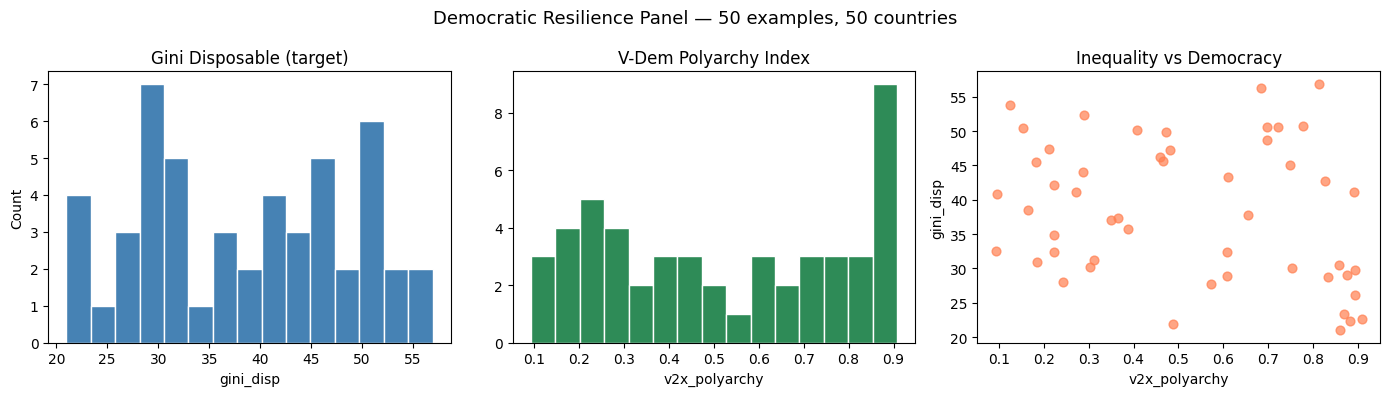


Variable                   N     Mean      Std      Min      Max
------------------------------------------------------------
gini_disp                 50    38.48    10.09    21.00    56.90
v2x_polyarchy             50     0.52     0.27     0.09     0.91
gdppc_maddison            48 10177.04 10053.38   744.14 36615.71
gdp_growth                50    -0.17     6.36   -19.60    16.21
terms_of_trade            29    95.12    59.35    39.27   364.64

Countries: ['AGO', 'ALB', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BIH', 'BLR', 'BOL', 'BRA', 'BRB', 'BTN', 'BWA'] ...


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Democratic Resilience Panel — {len(df)} examples, {df['iso3'].nunique()} countries", fontsize=13)

# 1. Gini distribution
axes[0].hist(df[OUTPUT_COL].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0].set_title("Gini Disposable (target)")
axes[0].set_xlabel("gini_disp")
axes[0].set_ylabel("Count")

# 2. Democracy index
if 'v2x_polyarchy' in df.columns:
    axes[1].hist(df['v2x_polyarchy'].dropna(), bins=15, color='seagreen', edgecolor='white')
    axes[1].set_title("V-Dem Polyarchy Index")
    axes[1].set_xlabel("v2x_polyarchy")

# 3. Gini vs Democracy scatter
if 'v2x_polyarchy' in df.columns:
    valid = df[[OUTPUT_COL, 'v2x_polyarchy']].dropna()
    axes[2].scatter(valid['v2x_polyarchy'], valid[OUTPUT_COL], alpha=0.7, color='coral', s=40)
    axes[2].set_title("Inequality vs Democracy")
    axes[2].set_xlabel("v2x_polyarchy")
    axes[2].set_ylabel("gini_disp")

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Variable':<22} {'N':>5} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for col in [OUTPUT_COL, 'v2x_polyarchy', 'gdppc_maddison', 'gdp_growth', 'terms_of_trade']:
    if col in df.columns:
        s = df[col].dropna()
        print(f"{col:<22} {len(s):>5} {s.mean():>8.2f} {s.std():>8.2f} {s.min():>8.2f} {s.max():>8.2f}")

print(f"\nCountries: {sorted(df['iso3'].dropna().unique().tolist())[:20]} ...")